In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/24-1/AI전공/PJ_FireForest/2.코드/my/

/content/drive/MyDrive/24-1/AI전공/PJ_FireForest/2.코드/my


In [3]:
pwd

'/content/drive/MyDrive/24-1/AI전공/PJ_FireForest/2.코드/my'

In [4]:
!pip list --format=freeze > requirements.txt

In [5]:
import sys
!{sys.executable} -m pip install  invisible-watermark > /dev/null

!pip install  \
    plotext \
    opencv-python \
    albumentations \
    tqdm \
    tabulate \
    install shapely \
    pillow \
    ipywidgets \
    accelerate==0.23.0 \
    validators==0.22.0 \
    diffusers==0.18.2 \
    transformers==4.32.1 \
    tensorboardX \
    pillow \
    ipywidgets \
    ipython > /dev/null && echo "Installation successful" || echo "Installation failed"

Installation successful


In [7]:
# %load fine_tune.py
import os
import warnings
import time
import gc
from typing import Tuple
from PIL import Image
from os.path import exists
import os
warnings.filterwarnings("ignore")

import torch
import numpy as np
import matplotlib.pyplot as plt
#import wandb
import seaborn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset

# from batch_finder import optimum_batch_size --> 64
default_batch_size = 64
from config import set_seed, device
from data_loader import (
    TRAIN_DIR,
    VALID_DIR,
    augment_and_save,
    data_distribution,
    imagenet_stats,
    img_transforms,
    plot_data_distribution,
    show_data,
)
from metrics import Metrics
from model import FireFinder
from trainer import Trainer
from lr_finder import LearningRateFinder
from torch import optim

OMP_NUM_THREADS set to: 1


In [8]:
def create_dataloader(
    directory: str, batch_size: int, shuffle: bool = False, transform=None
) -> DataLoader:
    """
    Create a DataLoader from a directory of images.

    Args:
        directory (str): Directory containing images.
        batch_size (int): Batch size for the DataLoader.
        shuffle (bool, optional): Whether to shuffle the data. Defaults to False.
        transform ([type], optional): Transformations to apply to the images. Defaults to None.

    Returns:
        DataLoader: DataLoader with images from the directory.
    """
    data = datasets.ImageFolder(directory, transform=transform)
    return DataLoader(data, batch_size=batch_size, shuffle=shuffle)


def setup_dataloaders(config: dict) -> Tuple[DataLoader, DataLoader]:
    """
    Setup train and validation DataLoaders.

    Args:
        config (dict): Configuration dictionary containing batch_size.

    Returns:
        Tuple[DataLoader, DataLoader]: A tuple containing train and validation dataloaders.
    """
    return create_dataloader(
        TRAIN_DIR, config["batch_size"], shuffle=True, transform=img_transforms["train"]
    ), create_dataloader(
        VALID_DIR, config["batch_size"], transform=img_transforms["valid"]
    )


def find_lr(model: FireFinder, optimizer: optim.Adam, dataloader: DataLoader) -> float:
    """
    Find best learning rate using Learning Rate Finder.

    Args:
        model (FireFinder): FireFinder model.
        optimizer (optim.Adam): Adam optimizer.
        dataloader (DataLoader): DataLoader with training data.

    Returns:
        float: Best learning rate.
    """
    lr_finder = LearningRateFinder(model, optimizer, device)
    best_lr = lr_finder.lr_range_test(dataloader, start_lr=1e-2, end_lr=1e-5)
    return best_lr


def train(model: FireFinder, trainer: Trainer, config: dict):
    """
    Train a FireFinder model.

    Args:
        model (FireFinder): FireFinder model.
        trainer (Trainer): Trainer to train the model.
        config (dict): Configuration dictionary containing learning rate and batch size.
    """
    train_dataloader, valid_dataloader = setup_dataloaders(config)
    print("training data")
    plot_data_distribution(data_distribution(train_dataloader.dataset, TRAIN_DIR))
    print("\nvalidation data")
    plot_data_distribution(data_distribution(valid_dataloader.dataset, VALID_DIR))
    print(f"______________")
    start = time.time()
    val_acc = trainer.fine_tune(train_dataloader, valid_dataloader)

    model_save_path = f"./models/model_acc_{val_acc}_device_{device}_lr_{trainer.lr}_epochs_{EPOCHS}.pt"
    torch.save(model.state_dict(), model_save_path)

    model.eval()
    with torch.no_grad():
        model_scripted = torch.jit.script(model)  # Export to TorchScript
        model_scripted.save(f"{model_save_path.replace('.pt','_jit.pt')}")  # Jit Save

    print(f"Model saved to :{model_save_path}")
    print(f"Time elapsed: {time.time() - start} seconds.")
    return (model_save_path)

Train folder data/colorEnhanced/train
Validation folder data/colorEnhanced/val
Using epoch: 3
Using Dropout: 0.3


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 156MB/s]


Running in Finetuning mode.
Using batch size: 64
Using learning rate: 0.000214
Running in Finetuning mode.
training data


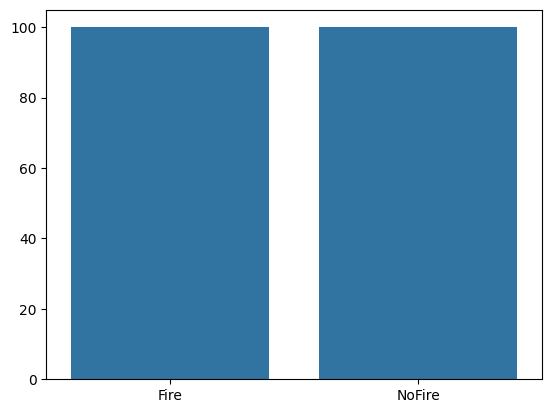


validation data


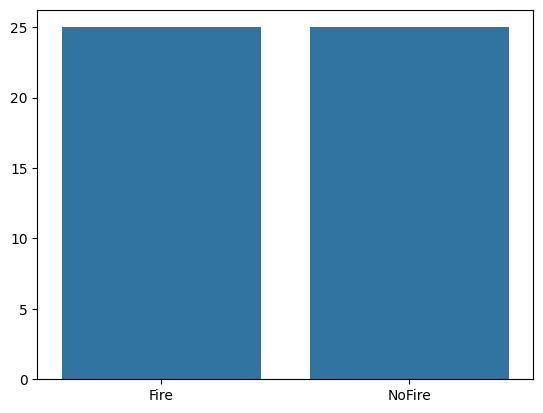

______________


100%|██████████| 1/1 [00:22<00:00, 22.07s/it]



📅 Epoch 1/3:
	🏋️‍♂️ Training step:
	 - 🎯 Loss: 0.3771, 📈 Accuracy: 0.7800
	🧪 Validation step:
	 - 🎯 Loss: 0.2919, 📈 Accuracy: 0.9000
⏱️ Time: 110.8839 sec



100%|██████████| 1/1 [00:05<00:00,  5.23s/it]



📅 Epoch 2/3:
	🏋️‍♂️ Training step:
	 - 🎯 Loss: 0.0613, 📈 Accuracy: 0.9750
	🧪 Validation step:
	 - 🎯 Loss: 0.0668, 📈 Accuracy: 0.9800
⏱️ Time: 64.5896 sec



100%|██████████| 1/1 [00:05<00:00,  5.83s/it]



📅 Epoch 3/3:
	🏋️‍♂️ Training step:
	 - 🎯 Loss: 0.0084, 📈 Accuracy: 1.0000
	🧪 Validation step:
	 - 🎯 Loss: 0.0119, 📈 Accuracy: 1.0000
⏱️ Time: 63.3565 sec

Model saved to :./models/model_acc_100_device_cpu_lr_0.000214_epochs_3.pt
Time elapsed: 240.02471613883972 seconds.


In [9]:
#mini version
# hyper params
EPOCHS = 3
DROPOUT = .3
# LR would be changed if we are using a LR finder
LR = 2.14e-4
#LR = 3.e-3
TEST_DIR = 'data/colorEnhanced/'
BATCH_SIZE = 64 #128  # Default batch size

aug_data = False
find_batch = False
find_lr_rate = False
#use_wandb = False
# use_ipex=True

set_seed(42)
print(f"Train folder {TRAIN_DIR}")
print(f"Validation folder {VALID_DIR}")
print(f"Using epoch: {EPOCHS}")
print(f"Using Dropout: {DROPOUT}")

batch_size = BATCH_SIZE

if aug_data:
    print("Augmenting training and validation datasets...")
    t1 = time.time()
    augment_and_save(TRAIN_DIR)
    augment_and_save(VALID_DIR)
    print(f"Done Augmenting in {time.time() - t1} seconds...")

model = FireFinder(simple=True, dropout=DROPOUT)
optimizer = optim.Adam(model.parameters(), lr=LR)
if find_batch:
    print(f"Finding optimum batch size...")
    # batch_size = optimum_batch_size(model, input_size=(3, 224, 224))
    batch_size = default_batch_size
print(f"Using batch size: {batch_size}")

best_lr = LR
if find_lr_rate:
    print("Finding best init lr...")
    train_dataloader = create_dataloader(
        TRAIN_DIR,
        batch_size=batch_size,
        shuffle=True,
        transform=img_transforms["train"],
    )
    best_lr = find_lr(model, optimizer, train_dataloader)
    del model, optimizer
    gc.collect()
    # if device == torch.device("xpu"):
    #     torch.xpu.empty_cache()
print(f"Using learning rate: {best_lr}")

model = FireFinder(simple=True, dropout=DROPOUT)
trainer = Trainer(
    model=model,
    optimizer=optim.Adam,
    lr=best_lr,
    epochs=EPOCHS,
    device=device,
    #use_wandb=use_wandb,
    # use_ipex=use_ipex,  # using ipex or not depending on this flag
)
model_save_path = train(model, trainer, config={"lr": best_lr, "batch_size": batch_size})